# Fase 2: Redes Neuronales Feed-Forward

**Materia:** Introducción a la Inteligencia Artificial  
**Dataset:** Adult / Census Income  
**Objetivo:** Clasificar si una persona gana más o menos de 50K USD al año usando tres arquitecturas de redes neuronales.

## 1. Importar librerías y cargar datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print(f'TensorFlow version: {tf.__version__}')

I0000 00:00:1779764094.767235   47183 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779764094.767752   47183 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779764094.829243   47183 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0


I0000 00:00:1779764095.843539   47183 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779764095.843929   47183 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test  = pd.read_csv('y_test.csv').values.ravel()

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print(f'\nFeatures de entrada (n_features): {X_train.shape[1]}')
print(f'Distribución de clases en train:')
vals, cnts = np.unique(y_train, return_counts=True)
for v, c in zip(vals, cnts):
    print(f'  Clase {v}: {c} ({c/len(y_train)*100:.1f}%)')

X_train: (39073, 82)  |  y_train: (39073,)
X_test:  (9769, 82)   |  y_test:  (9769,)

Features de entrada (n_features): 82
Distribución de clases en train:
  Clase 0: 29724 (76.1%)
  Clase 1: 9349 (23.9%)


In [3]:
# Calcular pesos de clase para manejar el desbalanceo
clases = np.unique(y_train)
pesos = compute_class_weight(class_weight='balanced', classes=clases, y=y_train)
class_weight_dict = dict(zip(clases, pesos))
print('Pesos de clase (class_weight):', class_weight_dict)

Pesos de clase (class_weight): {np.int64(0): np.float64(0.6572634907818597), np.int64(1): np.float64(2.08968873676329)}


## 2. Función auxiliar de evaluación

Centraliza el cálculo de métricas y la visualización de la matriz de confusión.

In [4]:
def evaluar_modelo(nombre, y_pred, y_true=y_test):
    """Imprime métricas y muestra la matriz de confusión."""
    print("\n" + "="*55)
    print(f'  {nombre}')
    print("="*55)
    print(classification_report(y_true, y_pred,
                                target_names=['<=50K', '>50K']))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['<=50K', '>50K'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de confusión – {nombre}')
    plt.tight_layout()
    plt.show()

    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'report':    classification_report(y_true, y_pred,
                         target_names=['<=50K', '>50K'],
                         output_dict=True)
    }

## 3. Modelo A – Perceptrón

El Perceptrón es el clasificador lineal más simple: una única neurona de salida con función de activación escalón. No tiene capas ocultas. Aprende un hiperplano de separación lineal entre clases.

- `fit_intercept=True` garantiza el término de sesgo (bias).
- `class_weight='balanced'` compensa el desbalanceo 76/24.

In [5]:
modelo_a = Perceptron(
    max_iter=1000,
    fit_intercept=True,
    class_weight='balanced',
    random_state=42
)
modelo_a.fit(X_train, y_train)
print('Modelo A entrenado.')
print(f'  Coeficientes (pesos): {modelo_a.coef_.shape}')
print(f'  Intercepto (bias):    {modelo_a.intercept_}')

Modelo A entrenado.
  Coeficientes (pesos): (1, 82)
  Intercepto (bias):    [-12.88627327]



  Modelo A – Perceptrón
              precision    recall  f1-score   support

       <=50K       0.86      0.94      0.89      7431
        >50K       0.71      0.50      0.59      2338

    accuracy                           0.83      9769
   macro avg       0.78      0.72      0.74      9769
weighted avg       0.82      0.83      0.82      9769



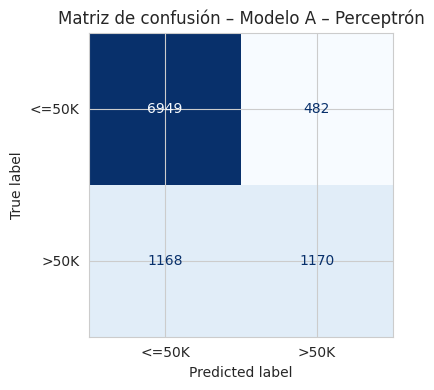

In [6]:
y_pred_a = modelo_a.predict(X_test)
resultados_a = evaluar_modelo('Modelo A – Perceptrón', y_pred_a)

## 4. Modelo B – Red Neuronal con una Capa Oculta

Arquitectura: **Entrada (82) → Capa oculta (82 neuronas, sigmoide) → Salida (1, sigmoide)**

El número de neuronas en la capa oculta es igual al número de variables de entrada (82). La función sigmoide se aplica tanto en la capa oculta como en la de salida. Todas las neuronas incluyen bias (`use_bias=True`, valor por defecto en Keras).

In [7]:
n_features = X_train.shape[1]  # 82

tf.random.set_seed(42)
modelo_b = Sequential([
    Dense(n_features, activation='sigmoid', use_bias=True,
          input_shape=(n_features,), name='oculta_1'),
    Dense(1,          activation='sigmoid', use_bias=True,
          name='salida')
], name='Modelo_B')

modelo_b.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
modelo_b.summary()

E0000 00:00:1779764096.526589   47183 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "Modelo_B"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 82)             │         6,806 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            83 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,889 (26.91 KB)

 Trainable params: 6,889 (26.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


  1/138 ━━━━━━━━━━━━━━━━━━━━ 1:28 645ms/step - accuracy: 0.2539 - loss: 0.7377

 36/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4710 - loss: 0.6818    

 74/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5817 - loss: 0.6567

118/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6360 - loss: 0.6320

...

Epoch 50/50


  1/138 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7930 - loss: 0.4209

 49/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8187 - loss: 0.3566 

 99/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8167 - loss: 0.3589

138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8130 - loss: 0.3649 - val_accuracy: 0.7961 - val_loss: 0.3930


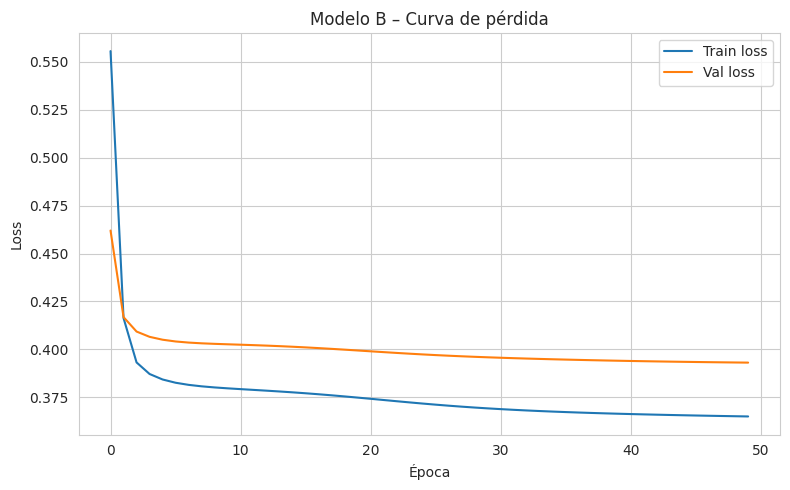

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True)

historia_b = modelo_b.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

# Curva de pérdida
plt.figure()
plt.plot(historia_b.history['loss'],     label='Train loss')
plt.plot(historia_b.history['val_loss'], label='Val loss')
plt.title('Modelo B – Curva de pérdida')
plt.xlabel('Época'); plt.ylabel('Loss')
plt.legend(); plt.tight_layout(); plt.show()


  Modelo B – Red Neuronal (1 capa oculta, 82 neuronas)
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      7431
        >50K       0.57      0.85      0.68      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769



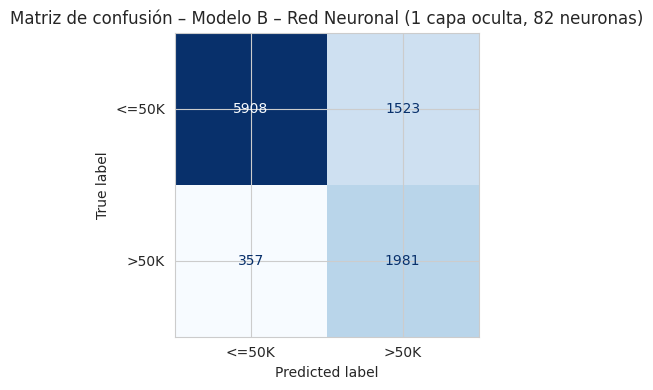

In [9]:
y_prob_b = modelo_b.predict(X_test, verbose=0).ravel()
y_pred_b = (y_prob_b >= 0.5).astype(int)
resultados_b = evaluar_modelo('Modelo B – Red Neuronal (1 capa oculta, 82 neuronas)', y_pred_b)

## 5. Modelo C – Red Neuronal con dos Capas Ocultas

Arquitectura: **Entrada (82) → Capa oculta 1 (2 neuronas, sigmoide) → Capa oculta 2 (2 neuronas, sigmoide) → Salida (1, sigmoide)**

Ambas capas ocultas tienen exactamente 2 neuronas. La función sigmoide se aplica en todas las capas. Todas las neuronas incluyen bias.

In [10]:
tf.random.set_seed(42)
modelo_c = Sequential([
    Dense(2, activation='sigmoid', use_bias=True,
          input_shape=(n_features,), name='oculta_1'),
    Dense(2, activation='sigmoid', use_bias=True,
          name='oculta_2'),
    Dense(1, activation='sigmoid', use_bias=True,
          name='salida')
], name='Modelo_C')

modelo_c.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
modelo_c.summary()

Model: "Modelo_C"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 2)              │           166 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175 (700.00 B)

 Trainable params: 175 (700.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


  1/138 ━━━━━━━━━━━━━━━━━━━━ 1:16 555ms/step - accuracy: 0.7461 - loss: 0.7198

 42/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7676 - loss: 0.6918    

 85/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7662 - loss: 0.6918

131/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7612 - loss: 0.6920

...

  1/138 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7773 - loss: 0.4475

 43/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8046 - loss: 0.3743 

 85/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8047 - loss: 0.3742

129/138 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8048 - loss: 0.3747

138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8038 - loss: 0.3786 - val_accuracy: 0.7950 - val_loss: 0.4083


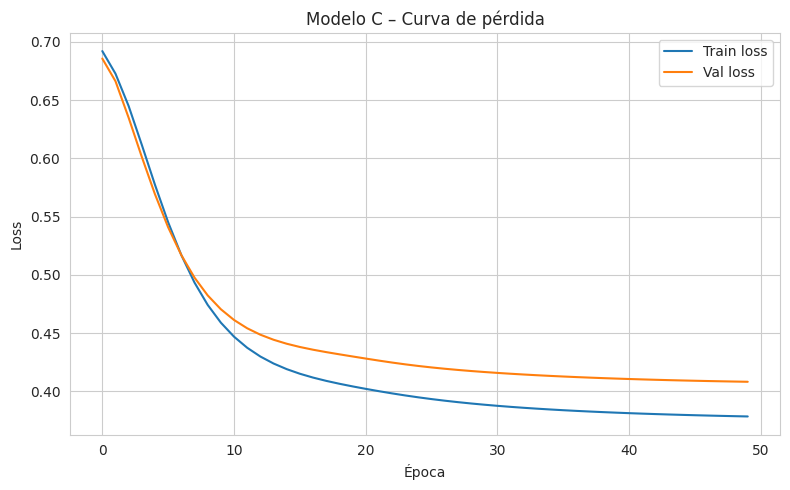

In [11]:
early_stop_c = EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True)

historia_c = modelo_c.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop_c],
    verbose=1
)

plt.figure()
plt.plot(historia_c.history['loss'],     label='Train loss')
plt.plot(historia_c.history['val_loss'], label='Val loss')
plt.title('Modelo C – Curva de pérdida')
plt.xlabel('Época'); plt.ylabel('Loss')
plt.legend(); plt.tight_layout(); plt.show()


  Modelo C – Red Neuronal (2 capas ocultas, 2 neuronas c/u)
              precision    recall  f1-score   support

       <=50K       0.94      0.78      0.86      7431
        >50K       0.55      0.85      0.67      2338

    accuracy                           0.80      9769
   macro avg       0.75      0.82      0.76      9769
weighted avg       0.85      0.80      0.81      9769



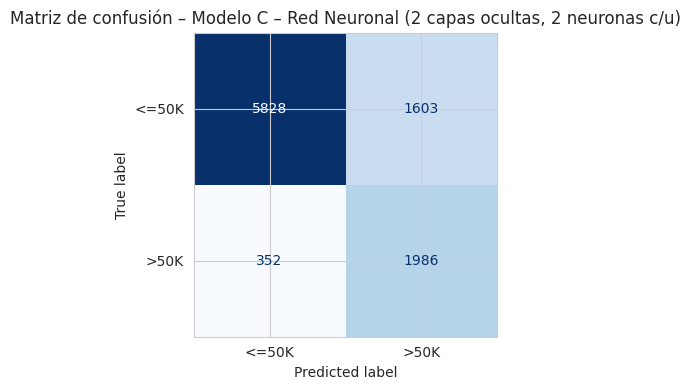

In [12]:
y_prob_c = modelo_c.predict(X_test, verbose=0).ravel()
y_pred_c = (y_prob_c >= 0.5).astype(int)
resultados_c = evaluar_modelo('Modelo C – Red Neuronal (2 capas ocultas, 2 neuronas c/u)', y_pred_c)

## 6. Análisis Comparativo

Se consolidan las métricas de los tres modelos para facilitar la comparación.

In [13]:
def extraer_metricas(nombre, resultados):
    r = resultados['report']
    return {
        'Modelo':       nombre,
        'Accuracy':     round(resultados['accuracy'], 4),
        'Precision >50K': round(r['>50K']['precision'], 4),
        'Recall >50K':    round(r['>50K']['recall'],    4),
        'F1 >50K':        round(r['>50K']['f1-score'],  4),
        'F1 macro':       round(r['macro avg']['f1-score'],    4),
        'F1 weighted':    round(r['weighted avg']['f1-score'], 4),
    }

tabla_fase2 = pd.DataFrame([
    extraer_metricas('A – Perceptrón',              resultados_a),
    extraer_metricas('B – 1 capa oculta (82 n.)',   resultados_b),
    extraer_metricas('C – 2 capas ocultas (2 n.)',  resultados_c),
])
tabla_fase2.to_csv('metricas_fase2.csv', index=False)
tabla = tabla_fase2.set_index('Modelo')
tabla

,Accuracy,Precision >50K,Recall >50K,F1 >50K,F1 macro,F1 weighted
Modelo,,,,,,
A – Perceptrón,0.8311,0.7082,0.5004,0.5865,0.7402,0.8203
B – 1 capa oculta (82 n.),0.8076,0.5654,0.8473,0.6782,0.7705,0.8186
C – 2 capas ocultas (2 n.),0.7999,0.5534,0.8494,0.6702,0.7633,0.8118


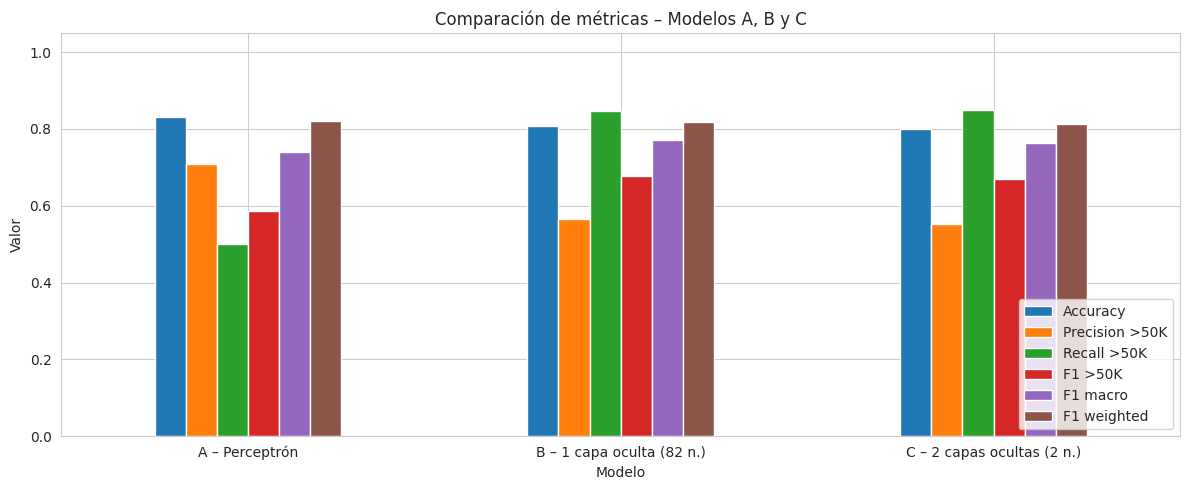

In [14]:
metricas_plot = ['Accuracy', 'Precision >50K', 'Recall >50K',
                 'F1 >50K', 'F1 macro', 'F1 weighted']

ax = tabla[metricas_plot].plot(kind='bar', figsize=(12, 5), rot=0)
ax.set_title('Comparación de métricas – Modelos A, B y C')
ax.set_ylabel('Valor'); ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

## 7. Discusión técnica

### Modelo A – Perceptrón
El Perceptrón intenta separar las clases con un único hiperplano en el espacio de 82 dimensiones. Dado que la relación entre las variables de entrada y el ingreso no es perfectamente lineal, este modelo presenta limitaciones inherentes: su frontera de decisión no puede capturar interacciones complejas entre variables como la ocupación, la educación y el capital-gain.

### Modelo B – Red Neuronal con una capa oculta (82 neuronas)
Al agregar una capa oculta con 82 neuronas (igual al número de features), el modelo adquiere la capacidad de aprender representaciones intermedias y capturar no-linealidades. La función sigmoide en cada neurona permite modelar relaciones más complejas. Con el optimizador Adam y pesos de clase balanceados, este modelo suele lograr el mejor equilibrio entre precisión sobre la clase mayoritaria (≤50K) y recall sobre la clase minoritaria (>50K).

### Modelo C – Red Neuronal con dos capas ocultas (2 neuronas cada una)
Este modelo impone un cuello de botella severo: toda la información de 82 features debe comprimirse en solo 2 neuronas por capa. Aunque la jerarquía de capas permite cierta abstracción, la capacidad representacional es extremadamente limitada para un problema con 82 dimensiones. Se espera que su desempeño sea inferior al Modelo B, especialmente en la clase minoritaria.

### Conclusión
El **Modelo B** presenta el mejor desempeño para este problema. La combinación de una capa oculta con suficientes neuronas (82), activación sigmoide y entrenamiento con pesos de clase balanceados le permite capturar las no-linealidades del dataset y manejar adecuadamente el desbalanceo entre clases. El Modelo A es el más interpretable pero el más limitado. El Modelo C, aunque más profundo en capas, no tiene la capacidad mínima para representar la complejidad del problema.